# Manual Crops — Phase 2 & 3 (Orient + Decode)

Batch pipeline for manually cropped barcodes in `manual_cropping/` (tilted / wrong orientation).

| Phase | What | Where |
|-------|------|-------|
| **1** | Detect & crop from full photos | `main.ipynb` + `barcode_detect.py` |
| **2** | Straighten via `minAreaRect` + `warpAffine` | here |
| **3** | Decode with pyzbar | here |

**Phase 2 notes:** 1D barcodes only need to be axis-aligned (horizontal or vertical bars). Pyzbar reads them upside down fine — text does not need to be at the bottom.

> `main.ipynb` stops after Phase 1. This notebook completes the pipeline for manual crops.

In [5]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import pandas as pd

from barcode_orient_decode import (
    decode_barcode,
    find_barcode_contour,
    orient_and_decode,
    straighten_barcode,
)

PROJECT_ROOT = Path(".").resolve()
INPUT_DIR = PROJECT_ROOT / "manual_cropping"

image_paths = sorted(p for p in INPUT_DIR.iterdir() if p.suffix.lower() in {".png", ".jpg", ".jpeg"})
print(f"Found {len(image_paths)} manual crop(s) in {INPUT_DIR}")
for path in image_paths:
    print(f"  - {path.name}")

Found 4 manual crop(s) in D:\D-Documents\WOrk\Interviews\Bar_Code_Assessment\manual_cropping
  - Screenshot 2026-06-24 210545.png
  - Screenshot 2026-06-24 210617.png
  - Screenshot 2026-06-24 210629.png
  - Screenshot 2026-06-24 210639.png


In [6]:
# Process every barcode image in manual_cropping/
results = []
for image_path in image_paths:
    image = cv2.imread(str(image_path))
    if image is None:
        results.append({"file": image_path.name, "error": "failed to read image"})
        continue

    result = orient_and_decode(image)
    if result is None:
        results.append({"file": image_path.name, "error": "decode failed"})
        continue

    results.append(
        {
            "file": image_path.name,
            "text": result.text,
            "type": result.barcode_type,
            "deskew_angle": result.deskew_angle,
            "rotation_angle": result.rotation_angle,
            "oriented_image": result.oriented_image,
            "raw_image": result.raw_image,
            "contour": result.contour,
        }
    )

rows = []
for item in results:
    if "error" in item:
        rows.append({"file": item["file"], "status": item["error"], "type": "", "deskew": "", "decoded": ""})
    else:
        rows.append(
            {
                "file": item["file"],
                "status": "OK",
                "type": item["type"],
                "deskew": f"{item['deskew_angle']:.1f}°",
                "decoded": item["text"],
            }
        )

summary = pd.DataFrame(rows)
print(f"Processed {len(image_paths)} image(s) — {sum(1 for r in results if 'error' not in r)} decoded\n")
summary

Processed 4 image(s) — 4 decoded



,file,status,type,deskew,decoded
0,Screenshot 2026-06-24 210545.png,OK,CODE39,-43.5°,ABC-1344
1,Screenshot 2026-06-24 210617.png,OK,CODE128,44.0°,120-122-10
2,Screenshot 2026-06-24 210629.png,OK,EAN8,34.0°,12349012
3,Screenshot 2026-06-24 210639.png,OK,EAN13,-31.9°,9027385325611


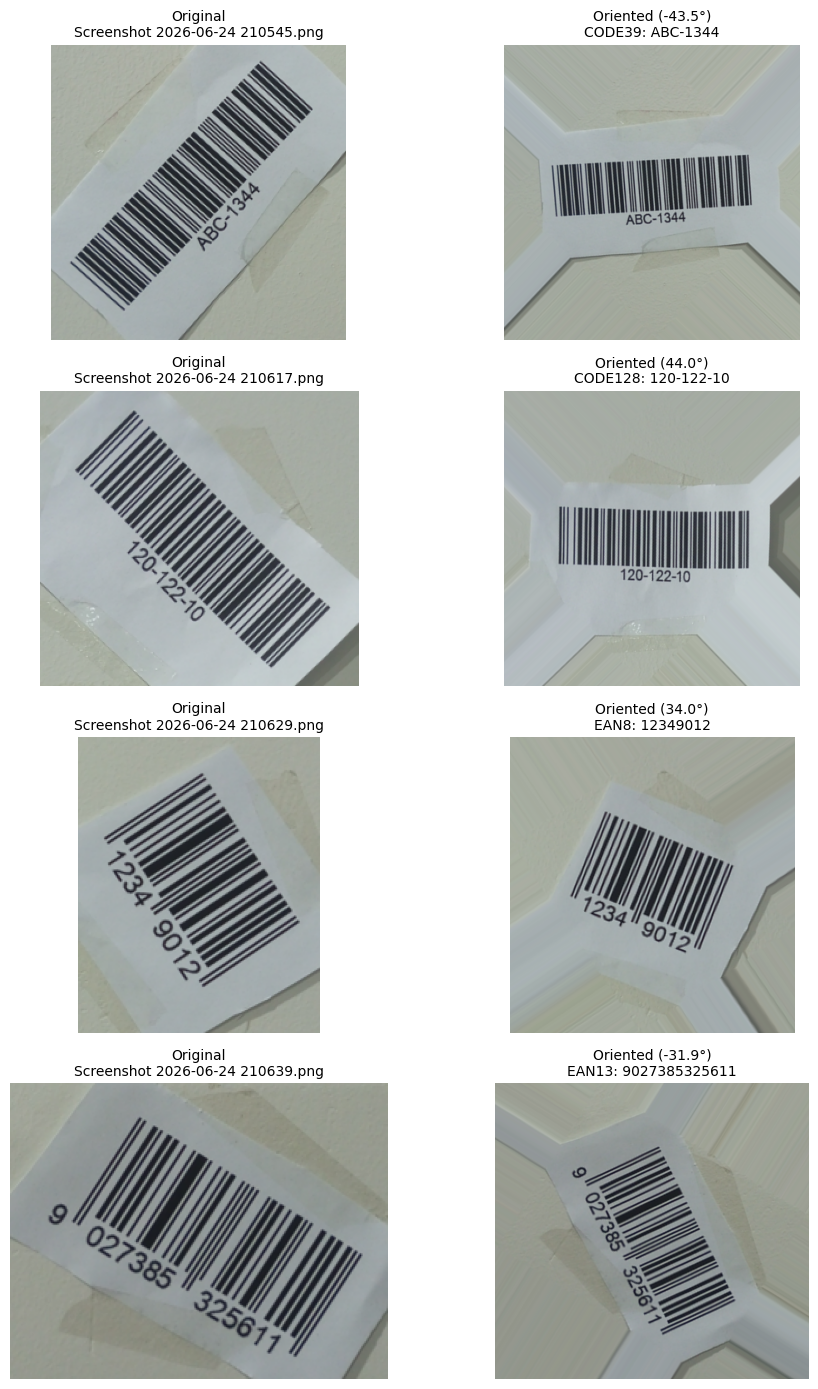

In [7]:
# Visualize every barcode: original vs oriented (or error message)
n = len(results)
fig, axes = plt.subplots(n, 2, figsize=(10, 3.5 * n))
if n == 1:
    axes = [axes]

for row_axes, item in zip(axes, results):
    if "error" in item:
        row_axes[0].text(0.5, 0.5, item["file"], ha="center", va="center", fontsize=10)
        row_axes[0].set_title("Original", fontsize=10)
        row_axes[0].axis("off")
        row_axes[1].text(0.5, 0.5, item["error"], ha="center", va="center", fontsize=12, color="red")
        row_axes[1].set_title("Failed", fontsize=10)
        row_axes[1].axis("off")
        continue

    original_rgb = cv2.cvtColor(item["raw_image"], cv2.COLOR_BGR2RGB)
    oriented_rgb = cv2.cvtColor(item["oriented_image"], cv2.COLOR_BGR2RGB)

    row_axes[0].imshow(original_rgb)
    row_axes[0].set_title(f"Original\n{item['file']}", fontsize=10)
    row_axes[0].axis("off")

    row_axes[1].imshow(oriented_rgb)
    row_axes[1].set_title(
        f"Oriented ({item['rotation_angle']:.1f}°)\n{item['type']}: {item['text']}",
        fontsize=10,
    )
    row_axes[1].axis("off")

plt.tight_layout()
plt.show()

In [8]:
# Phase 2 step-by-step for every barcode in manual_cropping/
print(f"{'File':<40} {'Deskew':>8}  {'Type':<10}  Decoded")
print("-" * 75)

for image_path in image_paths:
    sample = cv2.imread(str(image_path))
    if sample is None:
        print(f"{image_path.name:<40} {'—':>8}  {'—':<10}  failed to read")
        continue

    contour = find_barcode_contour(sample)
    straightened, deskew_angle, _ = straighten_barcode(sample, contour)
    decoded = decode_barcode(straightened)

    if decoded:
        text = decoded[0].data.decode("utf-8")
        btype = decoded[0].type
    else:
        # full pipeline also tries 0/90/180/270° on deskewed image
        full = orient_and_decode(sample)
        if full:
            text = full.text
            btype = full.type
        else:
            text = "DECODE FAILED"
            btype = "—"

    print(f"{image_path.name:<40} {deskew_angle:>7.1f}°  {btype:<10}  {text}")

File                                       Deskew  Type        Decoded
---------------------------------------------------------------------------
Screenshot 2026-06-24 210545.png           -43.5°  CODE39      ABC-1344
Screenshot 2026-06-24 210617.png            44.0°  CODE128     120-122-10
Screenshot 2026-06-24 210629.png            34.0°  EAN8        12349012
Screenshot 2026-06-24 210639.png           -31.9°  EAN13       9027385325611
